In [1]:
import pandas as pd, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PATH        = "data_without_straw.xlsx"
df = (pd.read_excel(PATH)
        .sort_values(["Participant_ID", "Time"])
        .reset_index(drop=True))

clf = tf.keras.models.load_model("Best_gesture_recognition_model.h5")

In [2]:
print("Columns in file:\n", df.columns.tolist(), "\n")

Columns in file:
 ['Time', 'Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_20', 'Zone_21', 'Zone_22', 'Zone_23', 'Zone_24', 'Zone_25', 'Zone_26', 'Zone_27', 'Zone_28', 'Zone_29', 'Zone_30', 'Zone_31', 'Zone_32', 'Zone_33', 'Zone_34', 'Zone_35', 'Zone_36', 'Zone_37', 'Zone_38', 'Zone_39', 'Zone_40', 'Zone_41', 'Zone_42', 'Zone_43', 'Zone_44', 'Zone_45', 'Zone_46', 'Zone_47', 'Zone_48', 'Zone_49', 'Zone_50', 'Zone_51', 'Zone_52', 'Zone_53', 'Zone_54', 'Zone_55', 'Zone_56', 'Zone_57', 'Zone_58', 'Zone_59', 'Zone_60', 'Zone_61', 'Zone_62', 'Zone_63', 'Label', 'Volume', 'Participant_ID', 'Actual_Volume', 'Straw'] 



In [3]:
print("---- Quick stats ------------------------------------------------")
print("Rows                    :", len(df))
print("Participants            :", df['Participant_ID'].nunique())
print("Frames flagged drinking :", (df["Label"]=="Drinking").sum())
print("Frames flagged Not-drinking :", (df["Label"]=="Not_Drinking").sum())
print("Any NaN in ActualVolume :", df['Actual_Volume'].isna().any())
print(df[['Actual_Volume']].describe())

---- Quick stats ------------------------------------------------
Rows                    : 80075
Participants            : 39
Frames flagged drinking : 5345
Frames flagged Not-drinking : 74730
Any NaN in ActualVolume : False
       Actual_Volume
count   80075.000000
mean      214.620803
std       119.327243
min       -31.150794
25%       130.837438
50%       179.960317
75%       271.428571
max       579.800000


In [4]:
df 

,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,Zone_8,...,Zone_59,Zone_60,Zone_61,Zone_62,Zone_63,Label,Volume,Participant_ID,Actual_Volume,Straw
0,1747823631000,2162,2155,3941,362,324,342,3605,2071,2121,...,242,225,232,257,1325,Not_Drinking,538.6,6,494.095238,N
1,1747823631200,2162,2155,3941,362,324,342,3605,2071,2121,...,242,225,232,257,1325,Not_Drinking,538.6,6,494.095238,N
2,1747823631400,2162,2155,3941,362,324,342,3605,2071,2121,...,242,225,232,257,1325,Not_Drinking,538.6,6,494.095238,N
3,1747823631600,2162,2155,3941,362,324,342,3605,2071,2121,...,242,225,232,257,1325,Not_Drinking,538.6,6,494.095238,N
4,1747823631800,2162,2155,3941,362,324,342,3605,2071,2121,...,242,225,232,257,1325,Not_Drinking,538.6,6,494.095238,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80070,17480259581000,133,230,129,245,117,114,106,97,1925,...,157,158,160,163,221,Not_Drinking,183.9,62,171.200000,N
80071,17480259641000,224,230,205,245,199,207,218,185,1955,...,155,152,147,151,221,Not_Drinking,183.9,62,171.200000,N
80072,17480259681000,133,204,205,1886,165,158,182,162,1955,...,147,152,147,151,173,Not_Drinking,183.9,62,171.200000,N
80073,17480259781000,214,204,1890,219,199,207,196,182,1937,...,148,152,155,164,173,Not_Drinking,183.9,62,171.200000,N


In [5]:

id_col      = "Participant_ID"
time_col    = "Time"
flag_col    = "Label"           # 'Drinking' / 'Not_Drinking'
vol_col     = "Actual_Volume"

# ────────────────────────────────────────────────────────────────
# 1. LOAD  +  MAP LABEL -> 0/1
# ────────────────────────────────────────────────────────────────


df[flag_col] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})


# ────────────────────────────────────────────────────────────────
# 2. FIND SIP BOUNDARIES
# ────────────────────────────────────────────────────────────────
df["prev"] = df.groupby(id_col)["Label"].shift(fill_value=0)
df["next"] = df.groupby(id_col)["Label"].shift(-1, fill_value=0)

df["sip_start"] = (df["prev"] == 0) & (df["Label"] == 1)        # first Drinking frame
df["sip_end"]   = (df["Label"] == 1) & (df["next"] == 0)        # last Drinking frame
df["sip_id"]    = df.groupby(id_col)["sip_start"].cumsum()       # 1,2,3,…

# rows where sip_start / sip_end are True
starts = df.loc[df["sip_start"]]
ends   = df.loc[df["sip_end"]]

# ────────────────────────────────────────────────────────────────
# 3.  PICK VOLUME BEFORE-START  &  AFTER-END
#     (guard against boundary rows)
# ────────────────────────────────────────────────────────────────
vol_before = (df.loc[starts.index - 1, vol_col]          # prev row
                .reset_index(drop=True)
                .rename("vol_before"))
vol_after  = (df.loc[ends.index + 1, vol_col]            # next row
                .reset_index(drop=True)
                .rename("vol_after"))

sip_delta = (pd.concat([starts[[id_col, "sip_id"]].reset_index(drop=True),
                        vol_before,
                        vol_after], axis=1)
               .dropna(subset=["vol_before", "vol_after"]))   # drop edges

sip_delta["dV"] = sip_delta["vol_before"] - sip_delta["vol_after"]
print("Non-zero ΔV rows:", (sip_delta["dV"] != 0).sum(), "/", len(sip_delta))
print(sip_delta["dV"].describe())

assert (sip_delta["dV"] != 0).any(), "ΔV still zero – check volume logging!"

# attach dV to every Drinking frame so we can build sequences
df = df.merge(sip_delta[[id_col, "sip_id", "dV"]],
              on=[id_col, "sip_id"], how="left")


Non-zero ΔV rows: 312 / 316
count    316.000000
mean      29.015881
std       23.513118
min        0.000000
25%       13.663075
50%       22.959354
75%       35.600000
max      160.200000
Name: dV, dtype: float64


In [6]:
df

,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,Zone_8,...,Volume,Participant_ID,Actual_Volume,Straw,prev,next,sip_start,sip_end,sip_id,dV
0,1747823631000,2162,2155,3941,362,324,342,3605,2071,2121,...,538.6,6,494.095238,N,0,0,False,False,0,NaN
1,1747823631200,2162,2155,3941,362,324,342,3605,2071,2121,...,538.6,6,494.095238,N,0,0,False,False,0,NaN
2,1747823631400,2162,2155,3941,362,324,342,3605,2071,2121,...,538.6,6,494.095238,N,0,0,False,False,0,NaN
3,1747823631600,2162,2155,3941,362,324,342,3605,2071,2121,...,538.6,6,494.095238,N,0,0,False,False,0,NaN
4,1747823631800,2162,2155,3941,362,324,342,3605,2071,2121,...,538.6,6,494.095238,N,0,0,False,False,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80070,17480259581000,133,230,129,245,117,114,106,97,1925,...,183.9,62,171.200000,N,0,0,False,False,7,26.1
80071,17480259641000,224,230,205,245,199,207,218,185,1955,...,183.9,62,171.200000,N,0,0,False,False,7,26.1
80072,17480259681000,133,204,205,1886,165,158,182,162,1955,...,183.9,62,171.200000,N,0,0,False,False,7,26.1
80073,17480259781000,214,204,1890,219,199,207,196,182,1937,...,183.9,62,171.200000,N,0,0,False,False,7,26.1


In [7]:
test=df.head(500) 
test.to_excel('sipadded.xlsx')

In [8]:
# M=pd.DataFrame(X)
# M=M.head(100) 
# M.to_exel('x.xlsx')

In [9]:
import pandas as pd
import numpy as np

# Display the initial structure of the dataset
# print("Initial DataFrame:")
# print(df.head())

# 1. Replace dV values for non-drinking parts and non-null NaN values
df['dV'] = df.apply(lambda row: 0 if row['Label'] == 0 or pd.isna(row['dV']) else row['dV'], axis=1)

# Display the number of rows and the updated DataFrame
# print("\nUpdated DataFrame with dV replaced:")
# print(df[['Participant_ID', 'sip_id', 'Label', 'dV']].head(20))
test=df.head(500) 
test.to_excel('sipadded.xlsx')
# df.to_excel('dv0_witoutstraw.xlsx')
print(df)

                 Time  Zone_0  Zone_1  Zone_2  Zone_3  Zone_4  Zone_5  Zone_6  \
0       1747823631000    2162    2155    3941     362     324     342    3605   
1       1747823631200    2162    2155    3941     362     324     342    3605   
2       1747823631400    2162    2155    3941     362     324     342    3605   
3       1747823631600    2162    2155    3941     362     324     342    3605   
4       1747823631800    2162    2155    3941     362     324     342    3605   
...               ...     ...     ...     ...     ...     ...     ...     ...   
80070  17480259581000     133     230     129     245     117     114     106   
80071  17480259641000     224     230     205     245     199     207     218   
80072  17480259681000     133     204     205    1886     165     158     182   
80073  17480259781000     214     204    1890     219     199     207     196   
80074  17480259821000     191     196    1890     217     173     173     182   

       Zone_7  Zone_8  ... 

In [11]:
from sklearn.model_selection import train_test_split

# # Split the data into training and testing sets, keeping the same random state for reproducibility
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Display the shapes of the resulting datasets
# print(f"\nShapes - X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

In [12]:
# # Reshape X for fitting to LSTM where each step is a single frame
# X_reshaped = X.reshape(X.shape[0], 1, X.shape[1])  # Each row as a single timestep

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)


In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset


# Replace non-drinking dV with 0 and keep drinking ones
df['dV'] = df.apply(lambda row: 0 if row['Label'] == 0 or pd.isna(row['dV']) else row['dV'], axis=1)

# Aggregate data by sip_id, summing the dV for frames of each sip
df_grouped = df.groupby('sip_id').agg({
    **{col: 'mean' for col in df.columns if col.startswith("Zone_")},  # Mean values for zones
    'dV': 'sum',                                      # Total volume for each sip
    'Participant_ID': 'first'  # Retrieve first participant ID for grouping
}).reset_index()

# Prepare features and target variable
sensor_cols = [col for col in df_grouped.columns if col.startswith("Zone_")]
X = df_grouped[sensor_cols + ['Participant_ID']].values
y = df_grouped['dV'].values  # The total volume for each sip

# Reshape X to have each sip's frames as one sequence
X_reshaped = X.reshape(X.shape[0], 1, X.shape[1])  # Each sip as a single timestep

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)


In [14]:
X_train

array([[[609.92082582, 418.9555021 , 600.04249349, ..., 336.54179194,
         383.41190619,  10.        ]],

       [[732.66101485, 463.83490099, 798.73490099, ..., 375.36980198,
         501.1710396 ,   6.        ]],

       [[712.26921496, 280.74229346, 797.73037402, ..., 249.82038635,
         296.19235512,  13.        ]],

       ...,

       [[575.99329288, 375.67039285, 620.19035452, ..., 271.77802619,
         255.420313  ,  13.        ]],

       [[771.46656051, 264.39649682, 703.98089172, ..., 240.75      ,
         321.70541401,  16.        ]],

       [[623.91788153, 483.28215538, 828.42147998, ..., 393.95460417,
         528.24856985,   6.        ]]])

In [15]:
X_test

array([[[ 913.50224327,  942.57801595, 1109.21161515,  987.20837488,
          930.94242273, 1006.25623131, 1291.44690927, 1346.94117647,
         1288.41550349, 1403.82228315, 1421.13235294, 1431.32103689,
         1458.10269192, 1541.96211366, 1417.38110668, 1254.35992024,
         1428.50373878, 1521.01570289, 1478.98080758, 1499.68394816,
         1737.18544367, 1690.27966102, 1623.31954138, 1207.85967099,
         1475.32976072, 1377.28763709, 1303.62063809, 1479.75772682,
         1605.80957129, 1652.4890329 , 1656.40179462, 1033.25922233,
         1122.89730808, 1213.74227318, 1169.71385842, 1173.34172483,
         1284.33773679, 1363.43045862, 1427.57352941,  787.29910269,
          858.72283151,  937.15079761,  786.87587238,  701.79162512,
          727.65254237,  796.50498504,  951.81306082,  944.9336989 ,
          690.78364905,  714.86989033,  491.02442672,  401.26694915,
          387.04511466,  452.03763709,  584.46410768,  592.75348953,
          451.59621137,  489.44591

Time         0
Zone_0       0
Zone_1       0
Zone_2       0
Zone_3       0
            ..
next         0
sip_start    0
sip_end      0
sip_id       0
dV           0
Length: 75, dtype: int64
                Time  Zone_0  Zone_1  Zone_2  Zone_3  Zone_4  Zone_5  Zone_6  \
241    1747823679200    2487     165     348    2497     297     255     279   
242    1747823679400    2487     165     348    2497     297     255     279   
243    1747823679600     265     200     234     245     277     255     279   
244    1747823679800     178     200     215     211     202     248     243   
245    1747823680000     178     200     210     192     176     207     243   
...              ...     ...     ...     ...     ...     ...     ...     ...   
79927  1748026308400     224     211     219     228     223     217     219   
79928  1748026308600     224     210     218     231     211     225     219   
79929  1748026308800     205     210     217     228     211     225     217   
79930  174

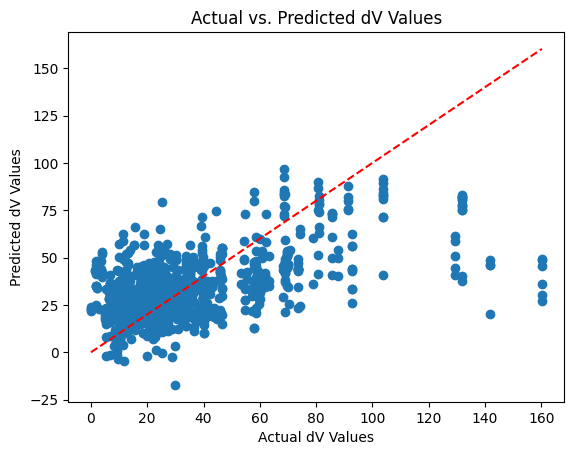

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

data = df[df['Label'] == 1]
data = data.drop(columns=["Volume"])

# Check for missing values and handle them if necessary
print(data.isnull().sum())
print(data)

# Input features: TOF readings from Zone_0 to Zone_63 and some categorical variables
X = data.drop(columns=["dV",'next','prev','Straw','Actual_Volume','sip_start','sip_end' ])
print('x',X)
print('y', y)
y = data["dV"]  # Target variable
print(len(X))  # Length of features
print(len(y))  
# Normalize the input features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Encode categorical variables if necessary
# Use pd.get_dummies if you decide to include Participant_ID or sip_id as features
# Example: X = pd.get_dummies(data, columns=["Participant_ID", "sip_id"])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()


# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print out the evaluation metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')

# Create a comparison table of actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df)

# Optionally save the comparison dataframe to a CSV file
comparison_df.to_csv('comparison_actual_vs_predicted.csv', index=False)

# Visualization of the predictions vs actual values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual dV Values')
plt.ylabel('Predicted dV Values')
plt.title('Actual vs. Predicted dV Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Diagonal line for reference
plt.show()

In [25]:
import pandas as pd

# Assuming df is your original DataFrame
data = df[df['Label'] == 1]
data = data.drop(columns=["Volume"])

# Check for missing values and handle them if necessary
print(data.isnull().sum())
print(data)

# Input features: TOF readings from Zone_0 to Zone_63, and some categorical variables
# Note: Ensure you handle 'sip_id' if used in the input features
X = data.drop(columns=["dV", 'next', 'prev', 'Straw', 'Actual_Volume', 'sip_start', 'sip_end'])
y = data["dV"]  # Target variable

print('X shape:', X.shape)
print('y shape:', y.shape)

# Unique SIP Sessions
unique_sip_ids = data['sip_id'].unique()

# Define the split using 80% of SIP sessions for training
split_index = int(len(unique_sip_ids) * 0.8)
train_sip_ids = unique_sip_ids[:split_index]

# Create training and testing datasets
train_data = data[data['sip_id'].isin(train_sip_ids)]
test_data = data[~data['sip_id'].isin(train_sip_ids)]

# Separate features and target variables
X_train = train_data.drop(columns=["dV", 'next', 'prev', 'Straw', 'Actual_Volume', 'sip_start', 'sip_end'])
y_train = train_data["dV"]

X_test = test_data.drop(columns=["dV", 'next', 'prev', 'Straw', 'Actual_Volume', 'sip_start', 'sip_end'])
y_test = test_data["dV"]
print('Training set shape:', X_train, y_train)
print('Testing set shape:', X_test, y_test)
# Print shapes of the resulting training and testing sets
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

# Normalize the input features if desired
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

Time         0
Zone_0       0
Zone_1       0
Zone_2       0
Zone_3       0
            ..
next         0
sip_start    0
sip_end      0
sip_id       0
dV           0
Length: 75, dtype: int64
                Time  Zone_0  Zone_1  Zone_2  Zone_3  Zone_4  Zone_5  Zone_6  \
241    1747823679200    2487     165     348    2497     297     255     279   
242    1747823679400    2487     165     348    2497     297     255     279   
243    1747823679600     265     200     234     245     277     255     279   
244    1747823679800     178     200     215     211     202     248     243   
245    1747823680000     178     200     210     192     176     207     243   
...              ...     ...     ...     ...     ...     ...     ...     ...   
79927  1748026308400     224     211     219     228     223     217     219   
79928  1748026308600     224     210     218     231     211     225     219   
79929  1748026308800     205     210     217     228     211     225     217   
79930  174

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam




# Reshape data for CNN and LSTM
X_train_reshaped = np.reshape(X_train.values, (X_train.shape[0], X_train.shape[1], 1))  # (samples, features, 1)
X_test_reshaped = np.reshape(X_test.values, (X_test.shape[0], X_test.shape[1], 1))  # (samples, features, 1)

# Define input shape for LSTM and CNN
input_shape = (X_train_reshaped.shape[1], 1)  # (timesteps, features)

def build_dnn_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))  # Use Input layer
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='linear'))  # Regression output
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

def build_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(1, activation='linear'))  # Regression output
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.3))
    
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    
    model.add(Dense(1, activation='linear'))  # Regression output
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

if __name__ == "__main__":
    # # Training DNN
    # dnn_model = build_dnn_model(input_shape=(X_train.shape[1],))  # Correct input shape
    # dnn_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

    # # Training CNN
    # cnn_model = build_cnn_model(input_shape=input_shape)  # Correct input shape
    # cnn_model.fit(X_train_reshaped, y_train, epochs=100, batch_size=32, verbose=1)

    # Training LSTM
    lstm_model = build_lstm_model(input_shape=(X_train_reshaped.shape[1], 1))  # Correct input shape
    lstm_model.fit(X_train_reshaped, y_train, epochs=100, batch_size=32, verbose=1)

    # Predictions and evaluations follow here...

Epoch 1/100


/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 1142.8007 - mae: 23.6469
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 750.6225 - mae: 19.6420
Epoch 3/100
 17/165 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 795.6080 - mae: 20.3577

In [ ]:
df

In [ ]:
y_train

In [ ]:
y_test

In [ ]:
X_test

In [ ]:
    for model_name, model, X_eval in [
        # 'DNN',dnn_model, X_test), ('CNN', cnn_model, X_test_reshaped), 
        ('LSTM', lstm_model, X_test_reshaped)]:
        print(f"Evaluating {model_name}...")
        y_pred = model.predict(X_eval)

        # Calculate evaluation metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        rmspe = np.sqrt(mse) / y_test.mean()
        # Print evaluation metrics
        print(f'{model_name} Evaluation Metrics:')
        print(f'Mean Squared Error (MSE): {mse}')
        print(f'Mean Absolute Error (MAE): {mae}')
        print(f'Root Mean Squared Error (RMSE): {rmse}')
        print(f'R² Score: {r2}')
        print(f"RMSPE {100*np.mean(rmspe):.2f}%")
        # Comparison DataFrame
        comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
        print(comparison_df.head(50))

In [ ]:
y_pred

In [ ]:
y_test.head(50)